#Import Libary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os

Load Data

## Manual

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/ML C Demo/Dataset Project3/train.csv', index_col=0)
data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


## EDA

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

In [5]:
data.shape

(1460, 80)

In [6]:
data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [7]:
#Missing Data
missing_data_counts = data.isnull().sum()
missing_data_percentages = (data.isnull().sum() / len(data)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data_counts,
    'Missing Percentage': missing_data_percentages
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Add a 'Data Type' column to missing_info
missing_info['Data Type'] = data[missing_info.index].dtypes

print("Missing Values Count and Percentage:")
display(missing_info)

Missing Values Count and Percentage:


,Missing Count,Missing Percentage,Data Type
PoolQC,1453,99.520548,object
MiscFeature,1406,96.301370,object
Alley,1369,93.767123,object
Fence,1179,80.753425,object
MasVnrType,872,59.726027,object
FireplaceQu,690,47.260274,object
LotFrontage,259,17.739726,float64
GarageType,81,5.547945,object
GarageYrBlt,81,5.547945,float64
GarageFinish,81,5.547945,object


### Missing Value
1. Dari data diatas terdapat 3 data numerik yang missing = LotFrontage, GarageYrBlt, MasVnrArea.
2. Untuk categorical yaitu : PoolQC, MiscFeature, Alley, Fence, MasVnrType, FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtExposure, BsmtFinType2, BsmtQual, BsmtCond, BsmtFinType1, Electrical.

In [8]:
#Check data duplikat
print("Jumlah duplikat:", data.duplicated().sum())
print(data[data.duplicated()])

Jumlah duplikat: 0
Empty DataFrame
Columns: [MSSubClass, MSZoning, LotFrontage, LotArea, Street, Alley, LotShape, LandContour, Utilities, LotConfig, LandSlope, Neighborhood, Condition1, Condition2, BldgType, HouseStyle, OverallQual, OverallCond, YearBuilt, YearRemodAdd, RoofStyle, RoofMatl, Exterior1st, Exterior2nd, MasVnrType, MasVnrArea, ExterQual, ExterCond, Foundation, BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinSF1, BsmtFinType2, BsmtFinSF2, BsmtUnfSF, TotalBsmtSF, Heating, HeatingQC, CentralAir, Electrical, 1stFlrSF, 2ndFlrSF, LowQualFinSF, GrLivArea, BsmtFullBath, BsmtHalfBath, FullBath, HalfBath, BedroomAbvGr, KitchenAbvGr, KitchenQual, TotRmsAbvGrd, Functional, Fireplaces, FireplaceQu, GarageType, GarageYrBlt, GarageFinish, GarageCars, GarageArea, GarageQual, GarageCond, PavedDrive, WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, PoolQC, Fence, MiscFeature, MiscVal, MoSold, YrSold, SaleType, SaleCondition, SalePrice]
Index: []

[0 rows x 80

In [9]:
#Import data float dan int ke numerik
for col in data.select_dtypes(include=np.number).columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("Data types after explicit numeric conversion:")
data.info()

Data types after explicit numeric conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond

In [10]:
data.head(5).T

Id,1,2,3,4,5
MSSubClass,60,20,60,70,60
MSZoning,RL,RL,RL,RL,RL
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450,9600,11250,9550,14260
Street,Pave,Pave,Pave,Pave,Pave
...,...,...,...,...,...
MoSold,2,5,9,2,12
YrSold,2008,2007,2008,2006,2008
SaleType,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Normal,Abnorml,Normal


## Histogram Data Numeric

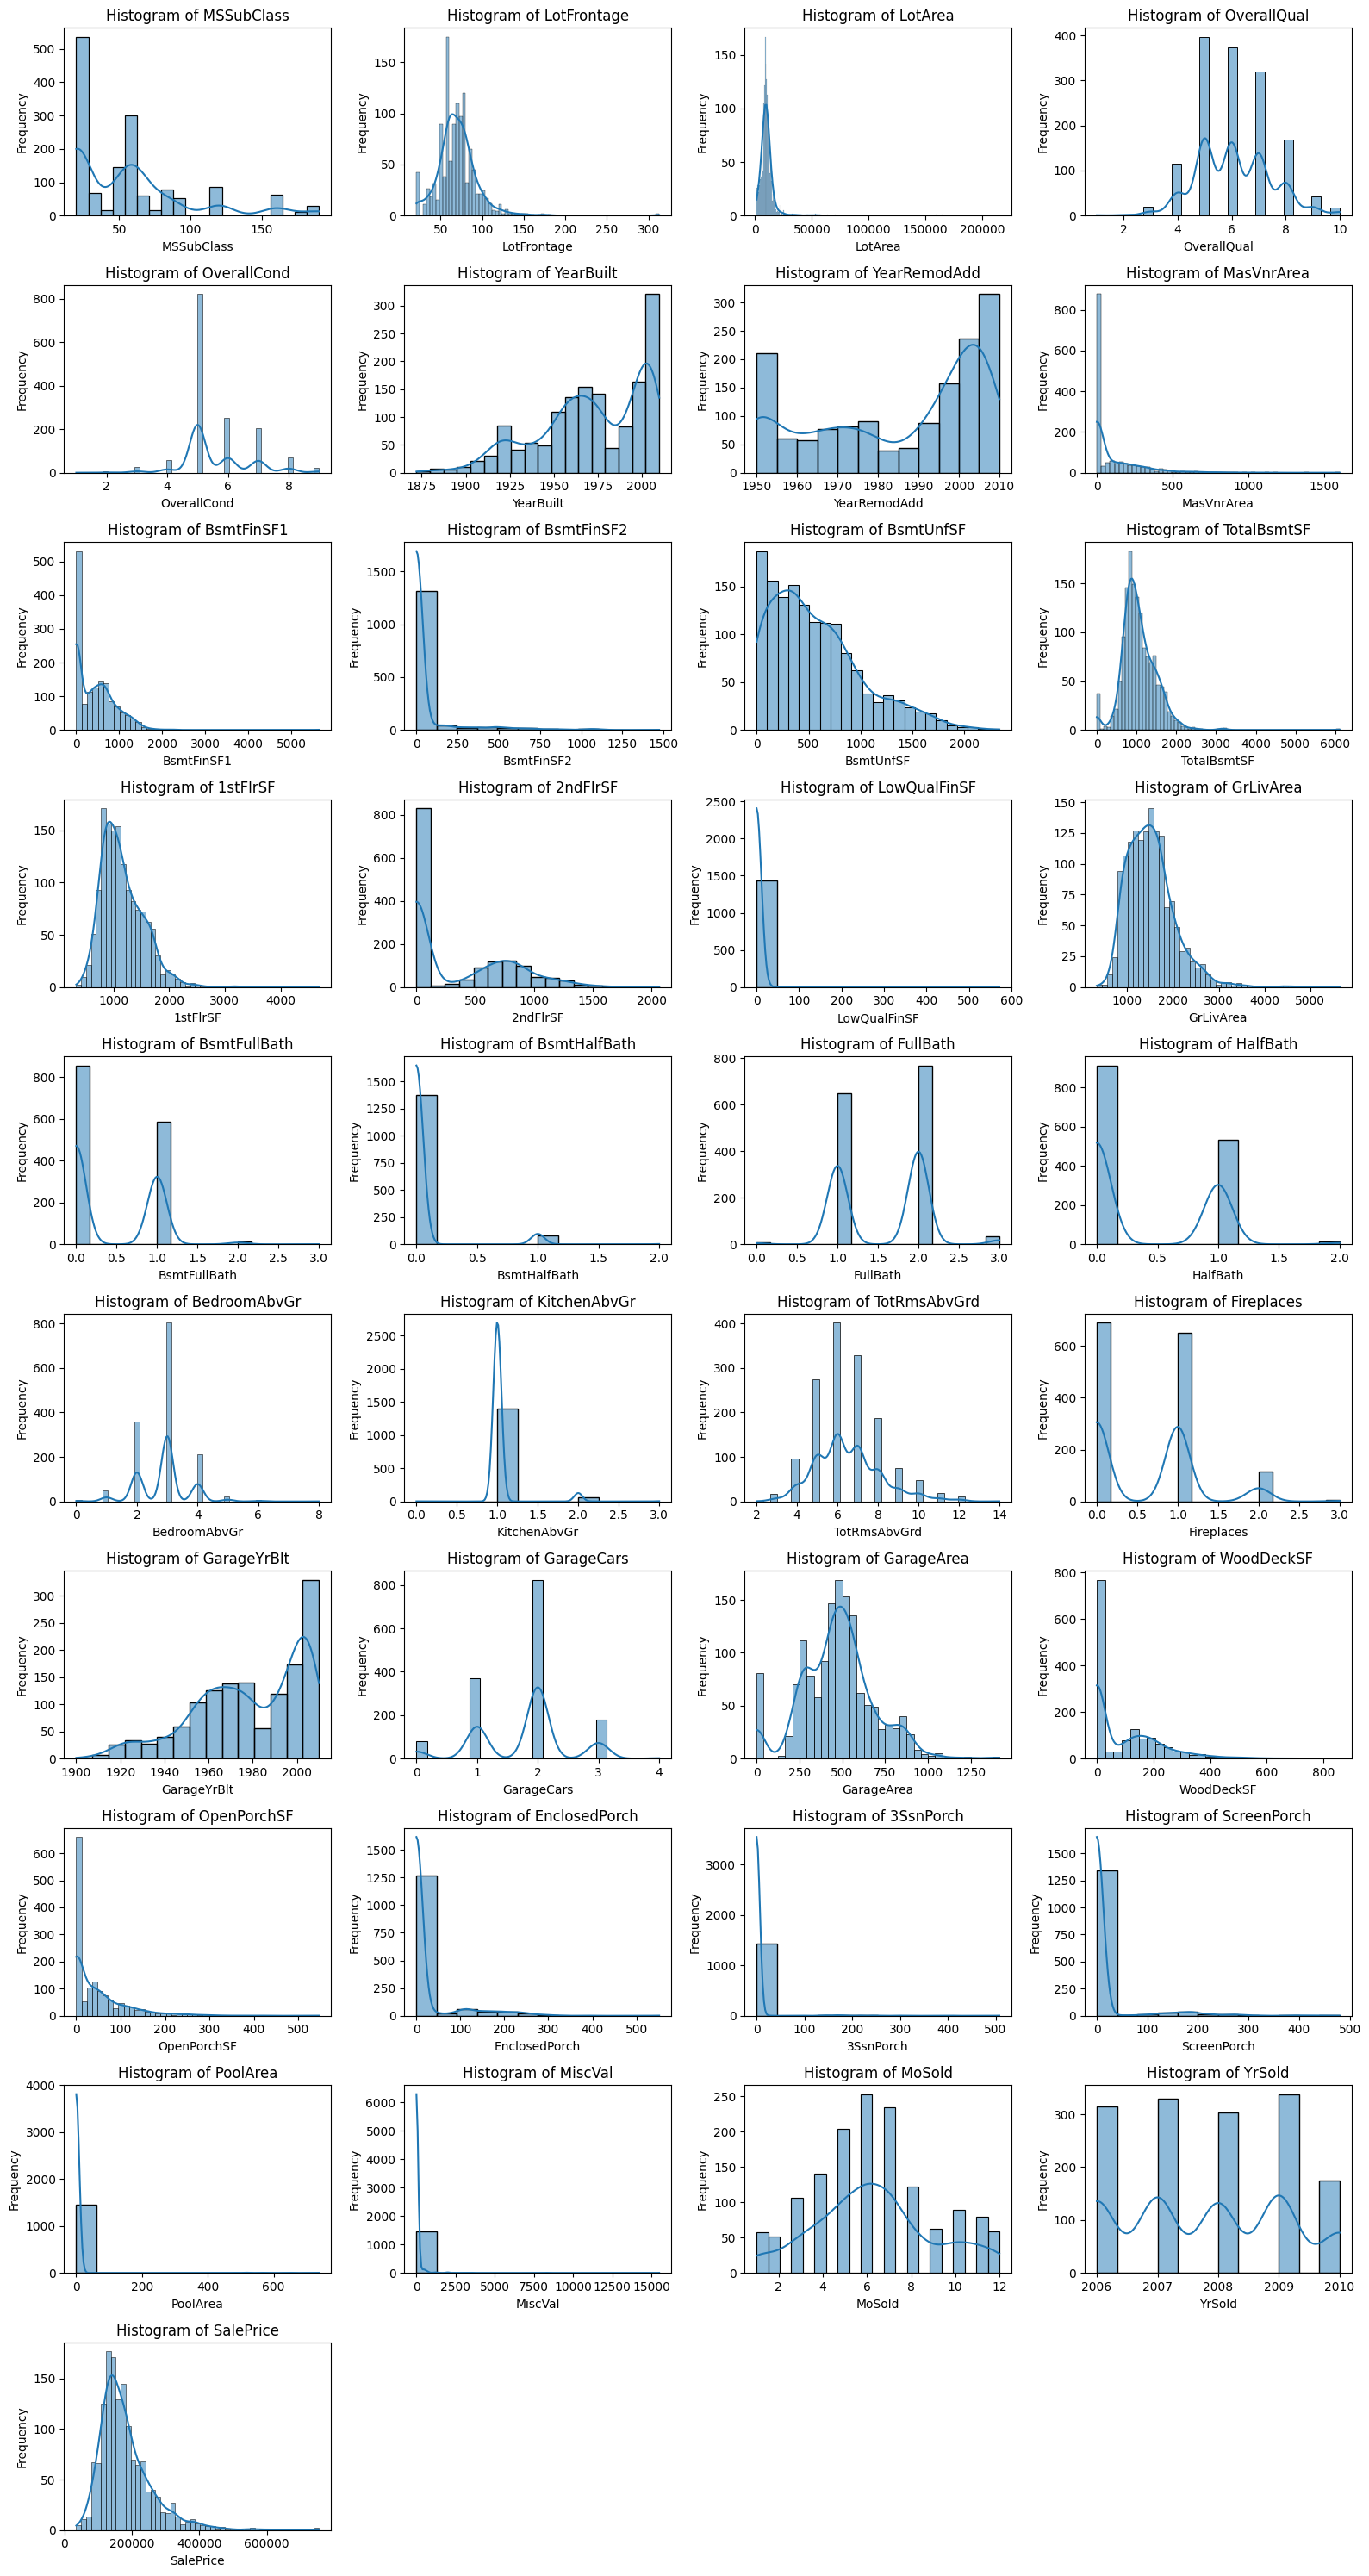

In [11]:
numeric_cols = data.select_dtypes(include=np.number).columns
num_plots = len(numeric_cols)

# Determine grid dimensions (e.g., 3 rows, 4 columns for 11 plots)
ncols = 4
nrows = (num_plots + ncols - 1) // ncols # Ceiling division to get enough rows

plt.figure(figsize=(4 * ncols, 3 * nrows)) # Adjust figure size based on individual plot size

for i, col in enumerate(numeric_cols):
    plt.subplot(nrows, ncols, i + 1) # Create subplot
    sns.histplot(data[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Barchart untuk data categorical

In [ ]:
categorical_cols = data.select_dtypes(include='object').columns
num_plots_cat = len(categorical_cols)

ncols_cat = 4
nrows_cat = (num_plots_cat + ncols_cat - 1) // ncols_cat

plt.figure(figsize=(4 * ncols_cat, 3 * nrows_cat)) # Adjust figure size

for i, col in enumerate(categorical_cols):
    plt.subplot(nrows_cat, ncols_cat, i + 1)
    sns.countplot(y=data[col], order=data[col].value_counts().index, palette='viridis', hue=data[col], legend=False)
    plt.title(f'Barchart of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## Histograms and Box Plots for Specific Numeric Columns with Missing Values

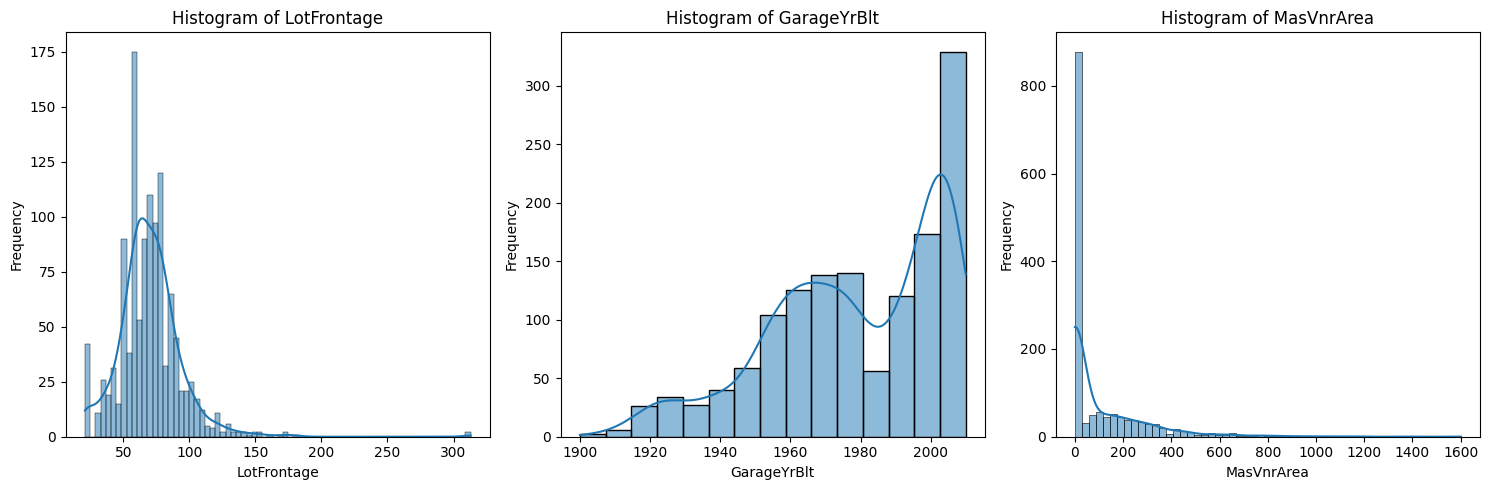

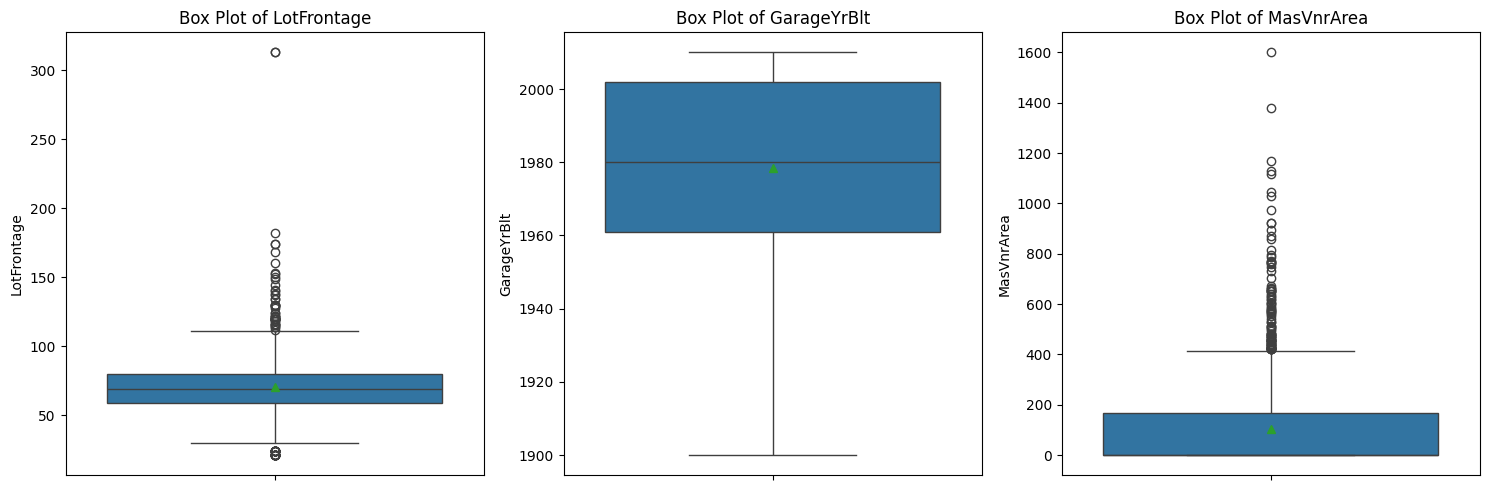


Skewness values:
LotFrontage: 2.16
GarageYrBlt: -0.65
MasVnrArea: 2.67


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns for plotting
columns_to_plot = ['LotFrontage', 'GarageYrBlt', 'MasVnrArea']

# Create histograms
plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Create box plots
plt.figure(figsize=(15, 5))
for i, col in enumerate(columns_to_plot):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=data[col].dropna(), showmeans=True)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# Display skewness for the specified columns
print("\nSkewness values:")
for col in columns_to_plot:
    print(f"{col}: {data[col].skew():.2f}")

## Imputing Missing Numerical Values
Dari histogram, boxplot dan skewness value didapat feature yang missing sedikit skewness sehingga untuk row data yang missing di feature diganti median Tapi sebelum itu dilihat dulu hubungan data missing dengan laim

In [ ]:
# Melihat hubungan missing value MasVnrArea dengan MasVnrType
missing_data_MasVnrArea = data.loc[data['MasVnrArea'].isnull(), ['MasVnrArea', 'MasVnrType']]
missing_data_MasVnrType = data.loc[data['MasVnrType'].isnull(), ['MasVnrType', 'MasVnrArea']]
print(missing_data_MasVnrArea)
print(missing_data_MasVnrType)

      MasVnrArea MasVnrType
Id                         
235          NaN        NaN
530          NaN        NaN
651          NaN        NaN
937          NaN        NaN
974          NaN        NaN
978          NaN        NaN
1244         NaN        NaN
1279         NaN        NaN
     MasVnrType  MasVnrArea
Id                         
2           NaN         0.0
4           NaN         0.0
6           NaN         0.0
9           NaN         0.0
10          NaN         0.0
...         ...         ...
1455        NaN         0.0
1456        NaN         0.0
1458        NaN         0.0
1459        NaN         0.0
1460        NaN         0.0

[872 rows x 2 columns]


MasVnrType: Jenis veneer pasangan bata

       1. BrkCmn	Bata umum
       2. BrkFace	Bata muka
       3. CBlock	Blok beton
       4. None	Tidak ada
       5. Stone	Batu

MasVnrArea: Luas area veneer pasangan bata dalam kaki persegi
Dari data diatas ada hubungan seharusnya row NAN pada column MasVnrArea seharusnya 0 sesuai dengan row di column MasVnrType Nan / Tidak ada.

In [ ]:
# Melihat hubungan missing value GarageYrBlt dengan GarageType dan GarageFinish
missing_data_GarageYrBlt = data.loc[data['GarageYrBlt'].isnull(), ['GarageYrBlt', 'GarageType','GarageFinish']]
print(missing_data_GarageYrBlt)

      GarageYrBlt GarageType GarageFinish
Id                                       
40            NaN        NaN          NaN
49            NaN        NaN          NaN
79            NaN        NaN          NaN
89            NaN        NaN          NaN
90            NaN        NaN          NaN
...           ...        ...          ...
1350          NaN        NaN          NaN
1408          NaN        NaN          NaN
1450          NaN        NaN          NaN
1451          NaN        NaN          NaN
1454          NaN        NaN          NaN

[81 rows x 3 columns]


Terlihat hubungan GarageYrBlt nilai NaN berarti Garage tidak ada GarageType dan GarageFinish

In [ ]:
# Impute missing values with the median for LotFrontage
if data['LotFrontage'].isnull().any():
    median_val_lotfrontage = data['LotFrontage'].median()
    data['LotFrontage'] = data['LotFrontage'].fillna(median_val_lotfrontage)
    print(f"Missing values in 'LotFrontage' imputed with median: {median_val_lotfrontage}")

# Impute missing values with 0 for GarageYrBlt and MasVnrArea as requested
if data['GarageYrBlt'].isnull().any():
    data['GarageYrBlt'] = data['GarageYrBlt'].fillna(0)
    print(f"Missing values in 'GarageYrBlt' imputed with 0")

if data['MasVnrArea'].isnull().any():
    data['MasVnrArea'] = data['MasVnrArea'].fillna(0)
    print(f"Missing values in 'MasVnrArea' imputed with 0")

# Verify that there are no more missing values in these columns
print("\nMissing values after imputation:")
display(data[['LotFrontage', 'GarageYrBlt', 'MasVnrArea']].isnull().sum())

Missing values in 'LotFrontage' imputed with median: 69.0
Missing values in 'GarageYrBlt' imputed with 0
Missing values in 'MasVnrArea' imputed with 0

Missing values after imputation:


,0
LotFrontage,0
GarageYrBlt,0
MasVnrArea,0


## Visualizing Frequency Distribution of Categorical Columns with Missing Values

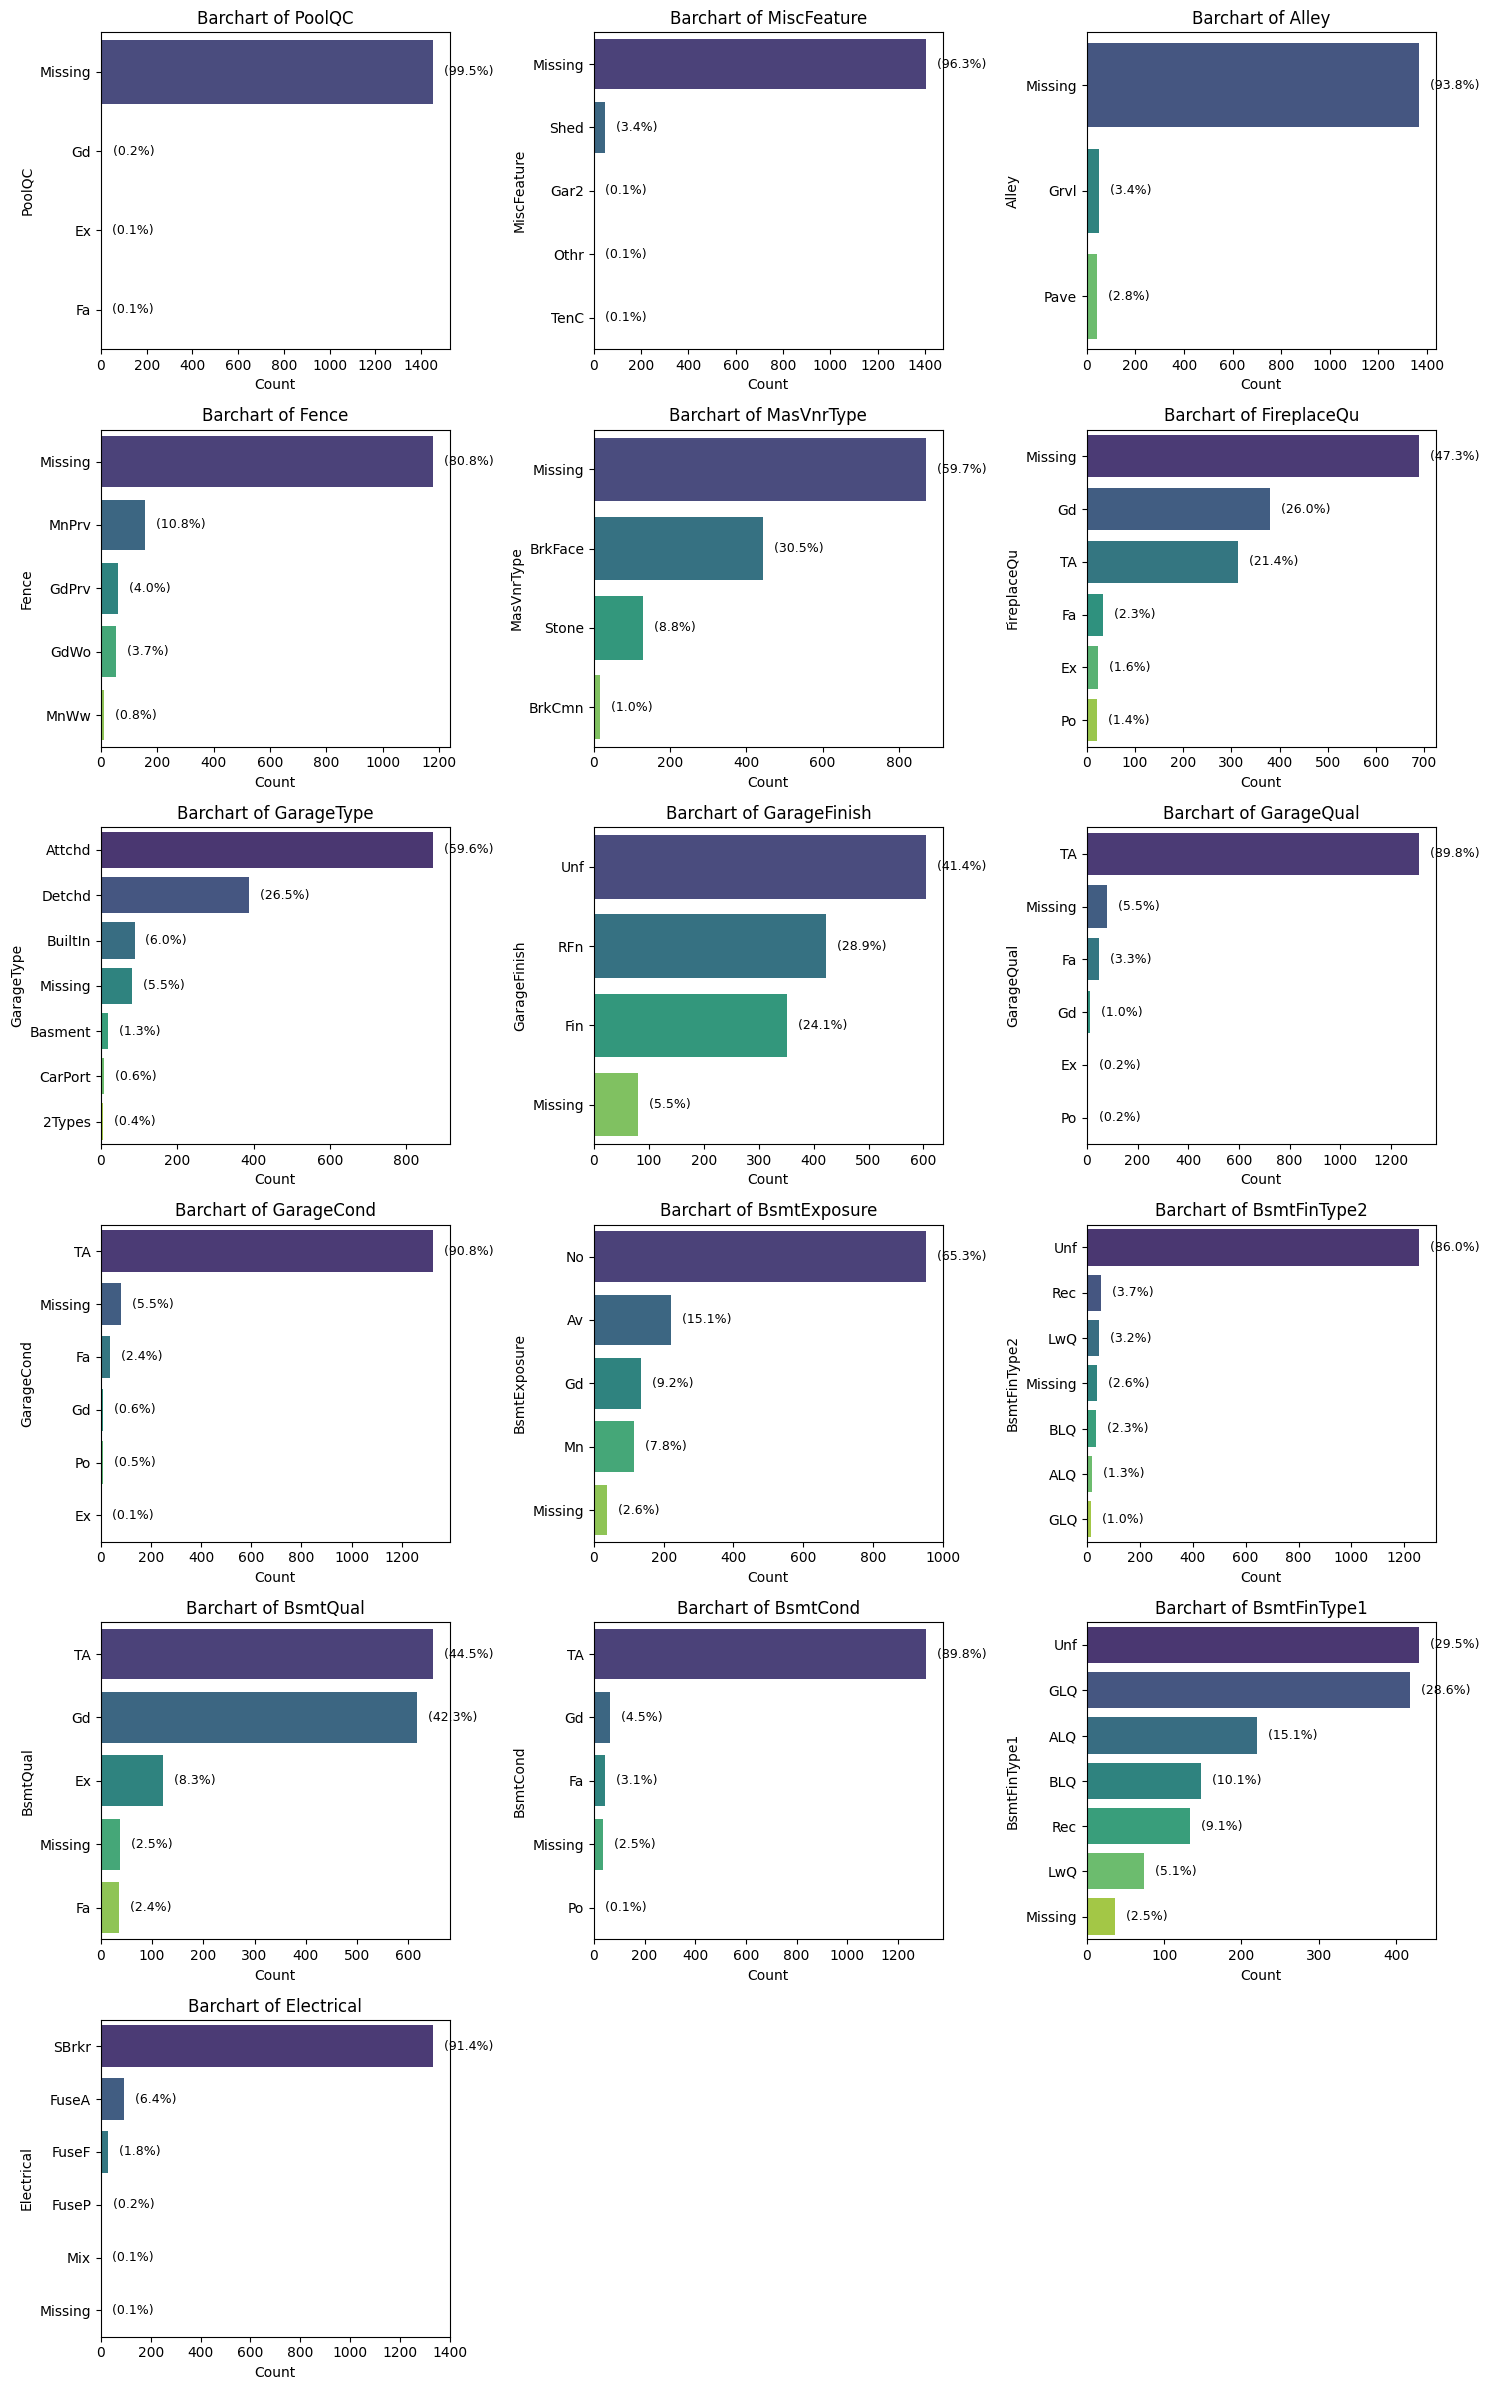

In [ ]:
categorical_missing_cols = missing_info[missing_info['Data Type'] == 'object'].index.tolist()

num_plots_cat_missing = len(categorical_missing_cols)
ncols_cat_missing = 3 # Adjust columns for better layout
rows_cat_missing = (num_plots_cat_missing + ncols_cat_missing - 1) // ncols_cat_missing

plt.figure(figsize=(5 * ncols_cat_missing, 4 * rows_cat_missing))

for i, col in enumerate(categorical_missing_cols):
    plt.subplot(rows_cat_missing, ncols_cat_missing, i + 1)

    # Get value counts and add a 'Missing' entry
    # Use value_counts(dropna=False) to get counts for NaN values
    plot_data = data[col].value_counts(dropna=False).reset_index(name='count')
    plot_data.rename(columns={'index': col}, inplace=True)

    # Replace NaN with 'Missing' label for plotting
    plot_data[col] = plot_data[col].fillna('Missing')

    ax = sns.barplot(x='count', y=col, data=plot_data, palette='viridis', hue=col, legend=False)
    plt.title(f'Barchart of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

    # Annotate each bar with its percentage
    total_count = len(data[col])
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            percentage = (width / total_count) * 100
            ax.text(width + ax.get_xlim()[1] * 0.02, bar.get_y() + bar.get_height() / 2, f' ({percentage:.1f}%)',
                    va='center', ha='left', color='black', fontsize=9)

plt.tight_layout()
plt.show()

## Imputing Missing Categorical Values
Dari missing value berdasarkan barchart didapatkan:
1.   >50% missing value : PoolQC, MiscFeature, Alley, Fence, MasVnrType.
2.   1% s/d 50% missing value : FireplaceQu, GarageType, GarageFinish, GarageQual, GarageCond, BsmtExposure, BsmtFinType2, BsmtQual, BsmtCond, BsmtFinType1.
3.    <1% missing value : Electrical

Pada missing value 1%-50% akan diisi dengan mode jika ada kategori yang lebih dari 60% dan diisin unknown jika tidak ada kategori yang lebih dari 60%. Maka didapat :
1. GarageQual, GarageCond, BsmtExposure, BsmtFinType2, BsmtCond (>60%).
2. FireplaceQu, GarageType, GarageFinish, BsmtQual, BsmtFinType1 (<60%).



In [ ]:
#Sebelum mengisi sesuai diatas, terlebih dahulu mencari hubungan garasi dengan GarageYrBlt
missing_data_GarageYrBlt = data.loc[data['GarageYrBlt']==0, ['GarageYrBlt', 'GarageType','GarageFinish','GarageQual', 'GarageCond']]
print(missing_data_GarageYrBlt)

      GarageYrBlt GarageType GarageFinish GarageQual GarageCond
Id                                                             
40            0.0        NaN          NaN        NaN        NaN
49            0.0        NaN          NaN        NaN        NaN
79            0.0        NaN          NaN        NaN        NaN
89            0.0        NaN          NaN        NaN        NaN
90            0.0        NaN          NaN        NaN        NaN
...           ...        ...          ...        ...        ...
1350          0.0        NaN          NaN        NaN        NaN
1408          0.0        NaN          NaN        NaN        NaN
1450          0.0        NaN          NaN        NaN        NaN
1451          0.0        NaN          NaN        NaN        NaN
1454          0.0        NaN          NaN        NaN        NaN

[81 rows x 5 columns]


In [ ]:
# Dari hubungan diatas bahwa nilai NaN merupakan none / tidak ada garasi maka diisi untuk missing value dengan kategori 'NA'
# Fill missing categorical columns with 'NA' as per domain knowledge
for col in ['GarageType','GarageFinish','GarageQual', 'GarageCond']:
    if data[col].isnull().any():
        data[col] = data[col].fillna('NA')
        print(f"Missing values in '{col}' filled with 'NA'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after 'NA' imputation:")
display(data[['GarageType','GarageFinish','GarageQual', 'GarageCond']].isnull().sum())

Missing values in 'GarageType' filled with 'NA'.
Missing values in 'GarageFinish' filled with 'NA'.
Missing values in 'GarageQual' filled with 'NA'.
Missing values in 'GarageCond' filled with 'NA'.

Missing values after 'NA' imputation:


,0
GarageType,0
GarageFinish,0
GarageQual,0
GarageCond,0


In [ ]:
# Melihat hubungan TotalBsmtSF dengan BsmtExposure, BsmtFinType2, BsmtQual, BsmtCond, BsmtFinType1
missing_data_Bsmt = data.loc[
    (data['BsmtExposure'].isnull()) | (data['BsmtFinType2'].isnull()),
    ['TotalBsmtSF', 'BsmtExposure', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1','BsmtUnfSF','BsmtFinSF1']]
print(missing_data_Bsmt)

      TotalBsmtSF BsmtExposure BsmtFinType2  BsmtFinSF2 BsmtQual BsmtCond  \
Id                                                                          
18              0          NaN          NaN           0      NaN      NaN   
40              0          NaN          NaN           0      NaN      NaN   
91              0          NaN          NaN           0      NaN      NaN   
103             0          NaN          NaN           0      NaN      NaN   
157             0          NaN          NaN           0      NaN      NaN   
183             0          NaN          NaN           0      NaN      NaN   
260             0          NaN          NaN           0      NaN      NaN   
333          3206           No          NaN         479       Gd       TA   
343             0          NaN          NaN           0      NaN      NaN   
363             0          NaN          NaN           0      NaN      NaN   
372             0          NaN          NaN           0      NaN      NaN   

In [ ]:
# Pada row 333 perlu diubah BsmtFinType2 menjadi kategori 'Unf' dan row 949 diubah BsmtExposure  menjadi kategori 'No'
data.at[949, 'BsmtExposure'] = 'No'
data.at[333, 'BsmtFinType2'] = 'Unf'


In [ ]:
cols_no_id = ['TotalBsmtSF','BsmtExposure', 'BsmtFinType2', 'BsmtCond', 'BsmtFinType1','BsmtFinSF2' ]

# Mengakses baris index 949
result = data.loc[[949], cols_no_id]
result1 = data.loc[[333], cols_no_id]
print(result)
print(result1)

     TotalBsmtSF BsmtExposure BsmtFinType2 BsmtCond BsmtFinType1  BsmtFinSF2
Id                                                                          
949          936           No          Unf       TA          Unf           0
     TotalBsmtSF BsmtExposure BsmtFinType2 BsmtCond BsmtFinType1  BsmtFinSF2
Id                                                                          
333         3206           No          Unf       TA          GLQ         479


In [ ]:
# Dari hubungan diatas bahwa nilai NaN merupakan none / tidak ada garasi maka diisi untuk missing value dengan kategori 'NA'
# Fill missing categorical columns with 'NA' as per domain knowledge
for col in ['BsmtFinType2', 'BsmtFinSF2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1','BsmtExposure']:
    if data[col].isnull().any():
        data[col] = data[col].fillna('NA')
        print(f"Missing values in '{col}' filled with 'NA'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after 'NA' imputation:")
display(data[['BsmtFinType2', 'BsmtFinSF2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1','BsmtExposure']].isnull().sum())

Missing values in 'BsmtFinType2' filled with 'NA'.
Missing values in 'BsmtQual' filled with 'NA'.
Missing values in 'BsmtCond' filled with 'NA'.
Missing values in 'BsmtFinType1' filled with 'NA'.
Missing values in 'BsmtExposure' filled with 'NA'.

Missing values after 'NA' imputation:


,0
BsmtFinType2,0
BsmtFinSF2,0
BsmtQual,0
BsmtCond,0
BsmtFinType1,0
BsmtExposure,0


In [ ]:
# Melihat hubungan FireplaceQu dengan Fireplaces
# Deteksi anomali Kalau Ada Fireplaces > 0 tapi FireplaceQu NaN
anomali = data[(data['Fireplaces'] > 0) & (data['FireplaceQu'].isna())]
print(f"Jumlah anomali: {len(anomali)}")
print(anomali[['Fireplaces', 'FireplaceQu']])

Jumlah anomali: 0
Empty DataFrame
Columns: [Fireplaces, FireplaceQu]
Index: []


In [ ]:
# Fill missing categorical columns with 'NA'
for col in ['FireplaceQu']:
    if data[col].isnull().any():
        data[col] = data[col].fillna('None')
        print(f"Missing values in '{col}' filled with 'NA'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after 'None' imputation:")
display(data[['FireplaceQu']].isnull().sum())

Missing values in 'FireplaceQu' filled with 'NA'.

Missing values after 'None' imputation:


,0
FireplaceQu,0


In [ ]:
# Fill missing categorical columns with mode
for col in ['Electrical']:
    if data[col].isnull().any():
        mode_val = data[col].mode()[0] # mode() can return multiple values, take the first one
        data[col] = data[col].fillna(mode_val)
        print(f"Missing values in '{col}' filled with mode: {mode_val}")

# Verify that there are no more missing values in these columns
print("\nMissing values after mode imputation:")
display(data[['Electrical']].isnull().sum())

Missing values in 'Electrical' filled with mode: SBrkr

Missing values after mode imputation:


,0
Electrical,0


In [ ]:
# MasVnrArea > 0 tapi MasVnrType None (anomali)
anomali = data[(data['MasVnrArea'] > 0) & (data['MasVnrType'] == 'None')]
print(f"Jumlah anomali: {len(anomali)}")

Jumlah anomali: 0


In [ ]:
# Dari data diatas tidak ada anomali bahwa  MasVnrArea = 0 sama persis jumlah nya dengan MasVnrType. Maka kita isi missing value dengan 'NA'
for col in ['MasVnrType']:
    if data[col].isnull().any():
        data[col] = data[col].fillna('None')
        print(f"Missing values in '{col}' filled with 'NA'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after 'None' imputation:")
display(data[['MasVnrType']].isnull().sum())


Missing values after 'None' imputation:


,0
MasVnrType,0


In [ ]:
# PoolArea > 0 tapi PoolQC None (anomali)
anomali_pool = data[(data['PoolArea'] > 0) & (data['PoolQC'] == 'None')]
print(f"Jumlah anomali: {len(anomali_pool)}")

Jumlah anomali: 0


In [ ]:
# MiscVal > 0 tapi MiscFeature None (anomali)
anomali_pool = data[(data['MiscVal'] > 0) & (data['MiscFeature'] == 'None')]
print(f"Jumlah anomali: {len(anomali)}")

Jumlah anomali: 0


In [ ]:
# Fill missing categorical columns with 'NA' as per domain knowledge
for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence',]:
    if data[col].isnull().any():
        data[col] = data[col].fillna('NA')
        print(f"Missing values in '{col}' filled with 'NA'.")

# Verify that there are no more missing values in these columns
print("\nMissing values after 'NA' imputation:")
display(data[['PoolQC', 'MiscFeature', 'Alley', 'Fence']].isnull().sum())

Missing values in 'PoolQC' filled with 'NA'.
Missing values in 'MiscFeature' filled with 'NA'.
Missing values in 'Alley' filled with 'NA'.
Missing values in 'Fence' filled with 'NA'.

Missing values after 'NA' imputation:


,0
PoolQC,0
MiscFeature,0
Alley,0
Fence,0


In [ ]:
#Missing Data
missing_data_counts = data.isnull().sum()
missing_data_percentages = (data.isnull().sum() / len(data)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_data_counts,
    'Missing Percentage': missing_data_percentages
})

missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

# Add a 'Data Type' column to missing_info
missing_info['Data Type'] = data[missing_info.index].dtypes

print("Missing Values Count and Percentage:")
display(missing_info)

Missing Values Count and Percentage:


,Missing Count,Missing Percentage,Data Type


## Data Type Category

In [ ]:
numerical_description = data.select_dtypes(include=['int64', 'float64']).agg(['min', 'max', 'mean', 'nunique']).T

# Calculate the most frequent value for each numerical column
most_frequent_numerical = data.select_dtypes(include=['int64', 'float64']).apply(lambda x: x.mode()[0] if not x.mode().empty else None)

# Calculate the percentage of the most frequent value for each numerical column
percentage_most_frequent_numerical = data.select_dtypes(include=['int64', 'float64']).apply(
    lambda x: (x.value_counts(normalize=True).iloc[0] * 100) if not x.mode().empty else None
)

# Add 'Most Frequent' and 'Percentage Most Frequent' to the numerical_description DataFrame
numerical_description['Most Frequent'] = most_frequent_numerical
numerical_description['Percentage Most Frequent'] = percentage_most_frequent_numerical

numerical_description = numerical_description.sort_values(by='Percentage Most Frequent', ascending=False)
display(numerical_description)

,min,max,mean,nunique,Most Frequent,Percentage Most Frequent
PoolArea,0.0,738.0,2.758904,8.0,0.0,99.520548
3SsnPorch,0.0,508.0,3.409589,20.0,0.0,98.356164
LowQualFinSF,0.0,572.0,5.844521,24.0,0.0,98.219178
MiscVal,0.0,15500.0,43.489041,21.0,0.0,96.438356
KitchenAbvGr,0.0,3.0,1.046575,4.0,1.0,95.342466
BsmtHalfBath,0.0,2.0,0.057534,3.0,0.0,94.383562
ScreenPorch,0.0,480.0,15.060959,76.0,0.0,92.054795
BsmtFinSF2,0.0,1474.0,46.549315,144.0,0.0,88.561644
EnclosedPorch,0.0,552.0,21.954110,120.0,0.0,85.753425
HalfBath,0.0,2.0,0.382877,3.0,0.0,62.534247


In [ ]:
data_cat = data.select_dtypes(include=['object', 'category'])
categorical_summary = []

for col in data_cat.columns:
    # Number of unique values
    n_unique = data_cat[col].nunique()

    # Most frequent unique value and its percentage
    value_counts = data_cat[col].value_counts(normalize=True)
    most_frequent_value = value_counts.index[0]
    percentage_most_frequent = value_counts.iloc[0] * 100

    categorical_summary.append({
        'Feature': col,
        'N_Unique': n_unique,
        'Most Frequent Value': most_frequent_value,
        'Percentage Most Frequent': f'{percentage_most_frequent:.2f}%'
    })

categorical_summary_df = pd.DataFrame(categorical_summary)
# Sort by 'Percentage Most Frequent' in descending order
categorical_summary_df['Percentage Most Frequent'] = categorical_summary_df['Percentage Most Frequent'].str.replace('%', '').astype(float)
categorical_summary_df = categorical_summary_df.sort_values(by='Percentage Most Frequent', ascending=False)
display(categorical_summary_df)

,Feature,N_Unique,Most Frequent Value,Percentage Most Frequent
5,Utilities,2,AllPub,99.93
1,Street,2,Pave,99.59
38,PoolQC,4,NA,99.52
10,Condition2,8,Norm,98.97
14,RoofMatl,8,CompShg,98.22
26,Heating,6,GasA,97.81
40,MiscFeature,5,NA,96.30
7,LandSlope,3,Gtl,94.66
2,Alley,3,NA,93.77
28,CentralAir,2,Y,93.49


## Feature Enginering / Selection

In [ ]:
# Action Items : Drop Kolom
#identifier = ['']

# Action Items : OHE
#category = ['']

# Action Items : Label Encoder (bertingkat) Manually, Grouping into a bigger group OR nunique more than 20 then drop
#df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Action Items : New Features = HouseAge
data['HouseAge'] = data['YrSold'] - data['YearBuilt']

# Action Items : New Features : RemodelAge
data['RemodelAge'] = data['YrSold'] - data['YearRemodAdd']

# Action Items : New Features : RemodelAge
data['GarageAge'] = data['YrSold'] - data['GarageYrBlt']

# Action Items : New Features : TotalSF (luas total)
data['TotalSF']= data['TotalBsmtSF'] + data['GrLivArea']

# Action Items : New Features : TotalPorsch (luas Porch / Teras)
data['TotalPorchSF'] = (data['OpenPorchSF'] + data['EnclosedPorch'] + data['ScreenPorch'])

# Action Items : New Features : TotalBath
data['TotalBath'] = (data['FullBath'] + data['BsmtFullBath'] + 0.5 * data['HalfBath'] + 0.5 * data['BsmtHalfBath'])

# Map FireplaceQu to numerical values for FireplaceScore
fireplace_quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, 'NA': 0} # 'NA' for actual missing, 'None' for no fireplace
data['FireplaceQu_Numeric'] = data['FireplaceQu'].map(fireplace_quality_map)
# Create FireplaceScore by multiplying numerical FireplaceQu with Fireplaces
data['FireplaceScore'] = data['Fireplaces'] * data['FireplaceQu_Numeric']

# Action Items : Target Variabel to Modelling
target = ['SalePrice']

In [ ]:
data.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,SaleCondition,SalePrice,HouseAge,RemodelAge,GarageAge,TotalSF,TotalPorchSF,TotalBath,FireplaceQu_Numeric,FireplaceScore
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,Inside,...,Normal,208500,5,5,5.0,2566,61,3.5,0,0
2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,FR2,...,Normal,181500,31,31,31.0,2524,0,2.5,3,3
3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,Inside,...,Normal,223500,7,6,7.0,2706,42,3.5,3,3
4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,Corner,...,Abnorml,140000,91,36,8.0,2473,307,2.0,4,4
5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,FR2,...,Normal,250000,8,8,8.0,3343,84,3.5,3,3


In [ ]:
data_num = data.select_dtypes(include=['int64', 'float64'])
data_num.head(5)
cols_to_drop = [
    # Identifier
    'Id',

    # Zero / near-zero variance
    'Utilities',       # AllPub
    'Street',          # Pave
    'RoofMatl',        # CompShg
    'Heating',         # GasA
    'KitchenAbvGr',    # bernilai 1
    '3SsnPorch',       # bernilai 0
    'LowQualFinSF',    # bernilai 0

    # High missing
    'Alley',           # ~93% missing
    'MiscFeature',     # ~96% missing
    'MiscVal',         # fitur mirip dengan MiscVal

    # Redundan setelah feature engineering
    'YearBuilt',       # HouseAge
    'YearRemodAdd',    # RemodelAge
    'GarageYrBlt',     # GarageAge
    'OpenPorchSF',
    'EnclosedPorch',
    'ScreenPorch',
    'TotalBsmtSF',
    'GrLivArea',
    'FireplaceQu_Numeric',
    'Fireplaces',
    'FullBath',
    'BsmtFullBath',
    'HalfBath',
    'BsmtHalfBath',
    'FireplaceQu',

    # Redundan antar fitur
    'GarageArea',      # sama dengan GarageCars
    'Condition2',      # hampir semua Norm
    'Exterior2nd',     # sama dengan Exterior1st

    # Near-zero variance kondisi
    'BsmtCond',        # TA
    'GarageQual',      # TA
    'GarageCond',      # TA
    'ExterCond',       # TA
    'PoolQC',          # None
]

data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Sisa fitur: {data.shape[1]}")

Sisa fitur: 55


In [ ]:
print(data_num.columns.tolist())

['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'FireplaceQu_Numeric', 'FireplaceScore']


In [ ]:
data_cat = data.select_dtypes(include=['object', 'category'])
print(data_cat.columns.tolist())

['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'MasVnrType', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'SaleType', 'SaleCondition']


### Label Encoding for Ordinal Categorical Features

I will now apply label encoding to several ordinal categorical features. This approach assigns a numerical value to each category based on its inherent order, which can be beneficial for machine learning models. The following columns will be encoded:

- `ExterQual`: Exterior quality (Excellent to Poor)
- `BsmtQual`: Basement height (Excellent to No Basement)
- `BsmtExposure`: Basement walkout or garden level walls (Good to No Exposure/No Basement)
- `BsmtFinType1`: Quality of basement finished area 1 (Good Living to Unfinished/No Basement)
- `BsmtFinType2`: Quality of basement finished area 2 (Good Living to Unfinished/No Basement)
- `HeatingQC`: Heating quality and condition (Excellent to Poor)
- `KitchenQual`: Kitchen quality (Excellent to Poor)
- `Functional`: Home functionality (Typical to Severely Damaged)
- `GarageFinish`: Interior finish of the garage (Finished to No Garage)
- `PavedDrive`: Paved driveway (Paved to Dirt/Gravel)
- `Fence`: Fence quality (Good Privacy to No Fence)

In [ ]:
# Define mappings for ordinal categorical columns, including LotShape and LandSlope
ordinal_mappings = {
    'LotShape': {'IR3': 0, 'IR2': 1, 'IR1': 2, 'Reg': 3},
    'LandSlope': {'Sev': 0, 'Mod': 1, 'Gtl': 2},
    'ExterQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
    'BsmtQual': {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0},
    'BsmtExposure': {'Gd': 3, 'Av': 2, 'Mn': 1, 'No': 0, 'NA': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'NA': 0},
    'HeatingQC': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
    'KitchenQual': {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0},
    'Functional': {'Typ': 7, 'Min1': 6, 'Min2': 5, 'Mod': 4, 'Maj1': 3, 'Maj2': 2, 'Sev': 1, 'Sal': 0},
    'GarageFinish': {'Fin': 2, 'RFn': 1, 'Unf': 0, 'NA': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0}
}

encoded_cols_success = []
skipped_cols = []

# Apply label encoding using a loop
for col, mapping in ordinal_mappings.items():
    if col in data.columns:
        data[col] = data[col].map(mapping) # Directly update the original column
        encoded_cols_success.append(col)
    else:
        skipped_cols.append(col)

if encoded_cols_success:
    print(f"Successfully encoded columns: {', '.join(encoded_cols_success)}")
if skipped_cols:
    print(f"Columns not found in DataFrame and skipped: {', '.join(skipped_cols)}")

print("\nFirst 5 rows with updated encoded columns:")
# Display the head of the DataFrame with the modified columns
if encoded_cols_success:
    display(data[encoded_cols_success].head())
else:
    print("No columns were encoded to display.")

Successfully encoded columns: LotShape, LandSlope, ExterQual, BsmtQual, BsmtExposure, BsmtFinType1, BsmtFinType2, HeatingQC, KitchenQual, Functional, GarageFinish, PavedDrive, Fence

First 5 rows with updated encoded columns:


,LotShape,LandSlope,ExterQual,BsmtQual,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,Functional,GarageFinish,PavedDrive,Fence
Id,,,,,,,,,,,,,
1,3,2,3,4,0,6,1,4,3,7,1,2,0
2,3,2,2,4,3,5,1,4,2,7,1,2,0
3,2,2,3,4,1,6,1,4,3,7,1,2,0
4,2,2,2,3,0,5,1,3,3,7,0,2,0
5,2,2,3,4,2,6,1,4,3,7,1,2,0


In [ ]:
data.shape[1]

55

## Label Encoder dengan Business Understanding

In [ ]:
data_cat = data.select_dtypes(include=['object', 'category'])
categorical_summary = []

for col in data_cat.columns:
    # Number of unique values
    n_unique = data_cat[col].nunique()

    # Most frequent unique value and its percentage
    value_counts = data_cat[col].value_counts(normalize=True)
    most_frequent_value = value_counts.index[0]
    percentage_most_frequent = value_counts.iloc[0] * 100

    categorical_summary.append({
        'Feature': col,
        'N_Unique': n_unique,
        'Most Frequent Value': most_frequent_value,
        'Percentage Most Frequent': f'{percentage_most_frequent:.2f}%'
    })

categorical_summary_df = pd.DataFrame(categorical_summary)
# Sort by 'Percentage Most Frequent' in descending order
categorical_summary_df['Percentage Most Frequent'] = categorical_summary_df['Percentage Most Frequent'].str.replace('%', '').astype(float)
categorical_summary_df = categorical_summary_df.sort_values(by='Percentage Most Frequent', ascending=False)
display(categorical_summary_df)

,Feature,N_Unique,Most Frequent Value,Percentage Most Frequent
11,CentralAir,2,Y,93.49
12,Electrical,5,SBrkr,91.44
1,LandContour,4,Lvl,89.79
14,SaleType,9,WD,86.78
4,Condition1,9,Norm,86.30
5,BldgType,5,1Fam,83.56
15,SaleCondition,6,Normal,82.05
0,MSZoning,5,RL,78.84
7,RoofStyle,6,Gable,78.15
2,LotConfig,5,Inside,72.05


In [ ]:
business_mappings = {
    'CentralAir': {'N': 1, 'Y': 2}, #Rumah tanpa AC → kurang diminati
    'Electrical': {'Mix': 1, 'FuseP': 2, 'FuseF': 3, 'FuseA': 4, 'SBrkr': 5}, #Sistem modern (circuit breaker) = lebih aman & premium
    'LandContour': {'Bnk': 1, 'Low': 2, 'Lvl': 3, 'HLS': 4}, #HLS = view bagus, Lvl = paling ideal untuk bangun rumah
    'SaleType': {'Oth': 1, 'COD': 2, 'ConLI': 3, 'ConLD': 4, 'ConLw': 5, 'WD': 6, 'CWD': 7, 'New': 8, 'Con': 9}, #Rumah baru (New) & kontrak fleksibel biasanya premium
    'Condition1': {'Artery': 1, 'Feedr': 2, 'RRAe': 3, 'RRAn': 4, 'RRNe': 5, 'Norm': 6, 'PosN': 7, 'PosA': 8, 'RRNn': 9}, #Dekat jalan besar → bising → turun value, PosA = dekat fasilitas bagus → naik value
    'BldgType': {'2fmCon': 1, 'Duplex': 2, 'Twnhs': 3, 'TwnhsE': 4, '1Fam': 5}, #Single-family = paling mahal (privasi tinggi)
    'SaleCondition': {'AdjLand': 1, 'Abnorml': 2, 'Family': 3, 'Alloca': 4, 'Normal': 5, 'Partial': 6}, #Partial = rumah baru → premium
    'MSZoning': {'C (all)': 1, 'RM': 2, 'RH': 3, 'RL': 4, 'FV': 5}, #FV = area modern / planned community
    'RoofStyle': {'Gambrel': 1, 'Gable': 2, 'Mansard': 3, 'Flat': 4, 'Hip': 5, 'Shed': 6}, #Hip & Shed → desain modern → lebih mahal
    'LotConfig': {'Inside': 1, 'Corner': 2, 'FR2': 3, 'FR3': 4, 'CulDSac': 5}, #Cul-de-sac = paling dicari (tenang, aman)
    'MasVnrType': {'None': 1, 'BrkCmn': 2, 'BrkFace': 3, 'Stone': 4}, #Stone = premium finish
    'GarageType': {'NA': 1, 'CarPort': 2, 'Detchd': 3, 'Basment': 4, '2Types': 5, 'Attchd': 6, 'BuiltIn': 7}, #Built-in = desain modern + praktis
    'HouseStyle': {'1.5Unf': 1, '1.5Fin': 2, 'SFoyer': 3, '1Story': 4, 'SLvl': 5, '2Story': 6, '2.5Unf': 7, '2.5Fin': 8}, #Lebih banyak lantai → lebih luas → lebih mahal
    'Foundation': {'Slab': 1, 'BrkTil': 2, 'Stone': 3, 'CBlock': 4, 'Wood': 5, 'PConc': 6}, #Poured concrete = paling kuat & modern
    'Exterior1st': {
                    'AsphShn': 1, 'BrkComm': 2, 'CBlock': 3, 'AsbShng': 4,
                    'Wd Sdng': 5, 'WdShing': 6, 'MetalSd': 7,
                    'HdBoard': 8, 'Stucco': 9, 'Plywood': 10,
                    'VinylSd': 11, 'BrkFace': 12, 'CemntBd': 13,
                    'Stone': 14, 'ImStucc': 15}, #Material premium → stone, stucco
    'Neighborhood': {
                    'MeadowV': 1, 'IDOTRR': 2, 'BrDale': 3, 'OldTown': 4, 'Edwards': 5,
                    'BrkSide': 6, 'Sawyer': 7, 'Blueste': 8, 'SWISU': 9, 'NAmes': 10,
                    'NPkVill': 11, 'Mitchel': 12, 'SawyerW': 13, 'Gilbert': 14, 'NWAmes': 15,
                    'Blmngtn': 16, 'CollgCr': 17, 'ClearCr': 18, 'Crawfor': 19,
                    'Veenker': 20, 'Somerst': 21, 'Timber': 22, 'StoneBr': 23,
                    'NoRidge': 24, 'NridgHt': 25 } #akses kota, keamanan, status sosial, fasilitas sekitar
    }

encoded_cols_success = []
skipped_cols = []

# Apply label encoding using a loop
for col, mapping in business_mappings.items():
    if col in data.columns:
        data[col] = data[col].map(mapping) # Directly update the original column
        encoded_cols_success.append(col)
    else:
        skipped_cols.append(col)

if encoded_cols_success:
    print(f"Successfully encoded columns: {', '.join(encoded_cols_success)}")
if skipped_cols:
    print(f"Columns not found in DataFrame and skipped: {', '.join(skipped_cols)}")

print("\nFirst 5 rows with updated encoded columns:")
# Display the head of the DataFrame with the modified columns
if encoded_cols_success:
    display(data[encoded_cols_success].head())
else:
    print("No columns were encoded to display.")

Successfully encoded columns: CentralAir, Electrical, LandContour, SaleType, Condition1, BldgType, SaleCondition, MSZoning, RoofStyle, LotConfig, MasVnrType, GarageType, HouseStyle, Foundation, Exterior1st, Neighborhood

First 5 rows with updated encoded columns:


,CentralAir,Electrical,LandContour,SaleType,Condition1,BldgType,SaleCondition,MSZoning,RoofStyle,LotConfig,MasVnrType,GarageType,HouseStyle,Foundation,Exterior1st,Neighborhood
Id,,,,,,,,,,,,,,,,
1,2,5,3,6,6,5,5,4,2,1,3,6,6,6,11,17
2,2,5,3,6,2,5,5,4,2,3,1,6,4,4,7,20
3,2,5,3,6,6,5,5,4,2,1,3,6,6,6,11,17
4,2,5,3,6,6,5,2,4,2,2,1,3,6,2,5,19
5,2,5,3,6,6,5,5,4,2,3,3,6,6,6,11,24


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MSSubClass      1460 non-null   int64  
 1   MSZoning        1460 non-null   int64  
 2   LotFrontage     1460 non-null   float64
 3   LotArea         1460 non-null   int64  
 4   LotShape        1460 non-null   int64  
 5   LandContour     1460 non-null   int64  
 6   LotConfig       1460 non-null   int64  
 7   LandSlope       1460 non-null   int64  
 8   Neighborhood    1460 non-null   int64  
 9   Condition1      1460 non-null   int64  
 10  BldgType        1460 non-null   int64  
 11  HouseStyle      1460 non-null   int64  
 12  OverallQual     1460 non-null   int64  
 13  OverallCond     1460 non-null   int64  
 14  RoofStyle       1460 non-null   int64  
 15  Exterior1st     1460 non-null   int64  
 16  MasVnrType      1460 non-null   int64  
 17  MasVnrArea      1460 non-null   float6

## Drop Numerik Fitur

In [ ]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_with_saleprice = data[numerical_cols].corr()['SalePrice'].sort_values(ascending=False)
display(correlation_with_saleprice)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
TotalSF,0.778959
Neighborhood,0.696158
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
TotalBath,0.631731
1stFlrSF,0.605852
BsmtQual,0.585207


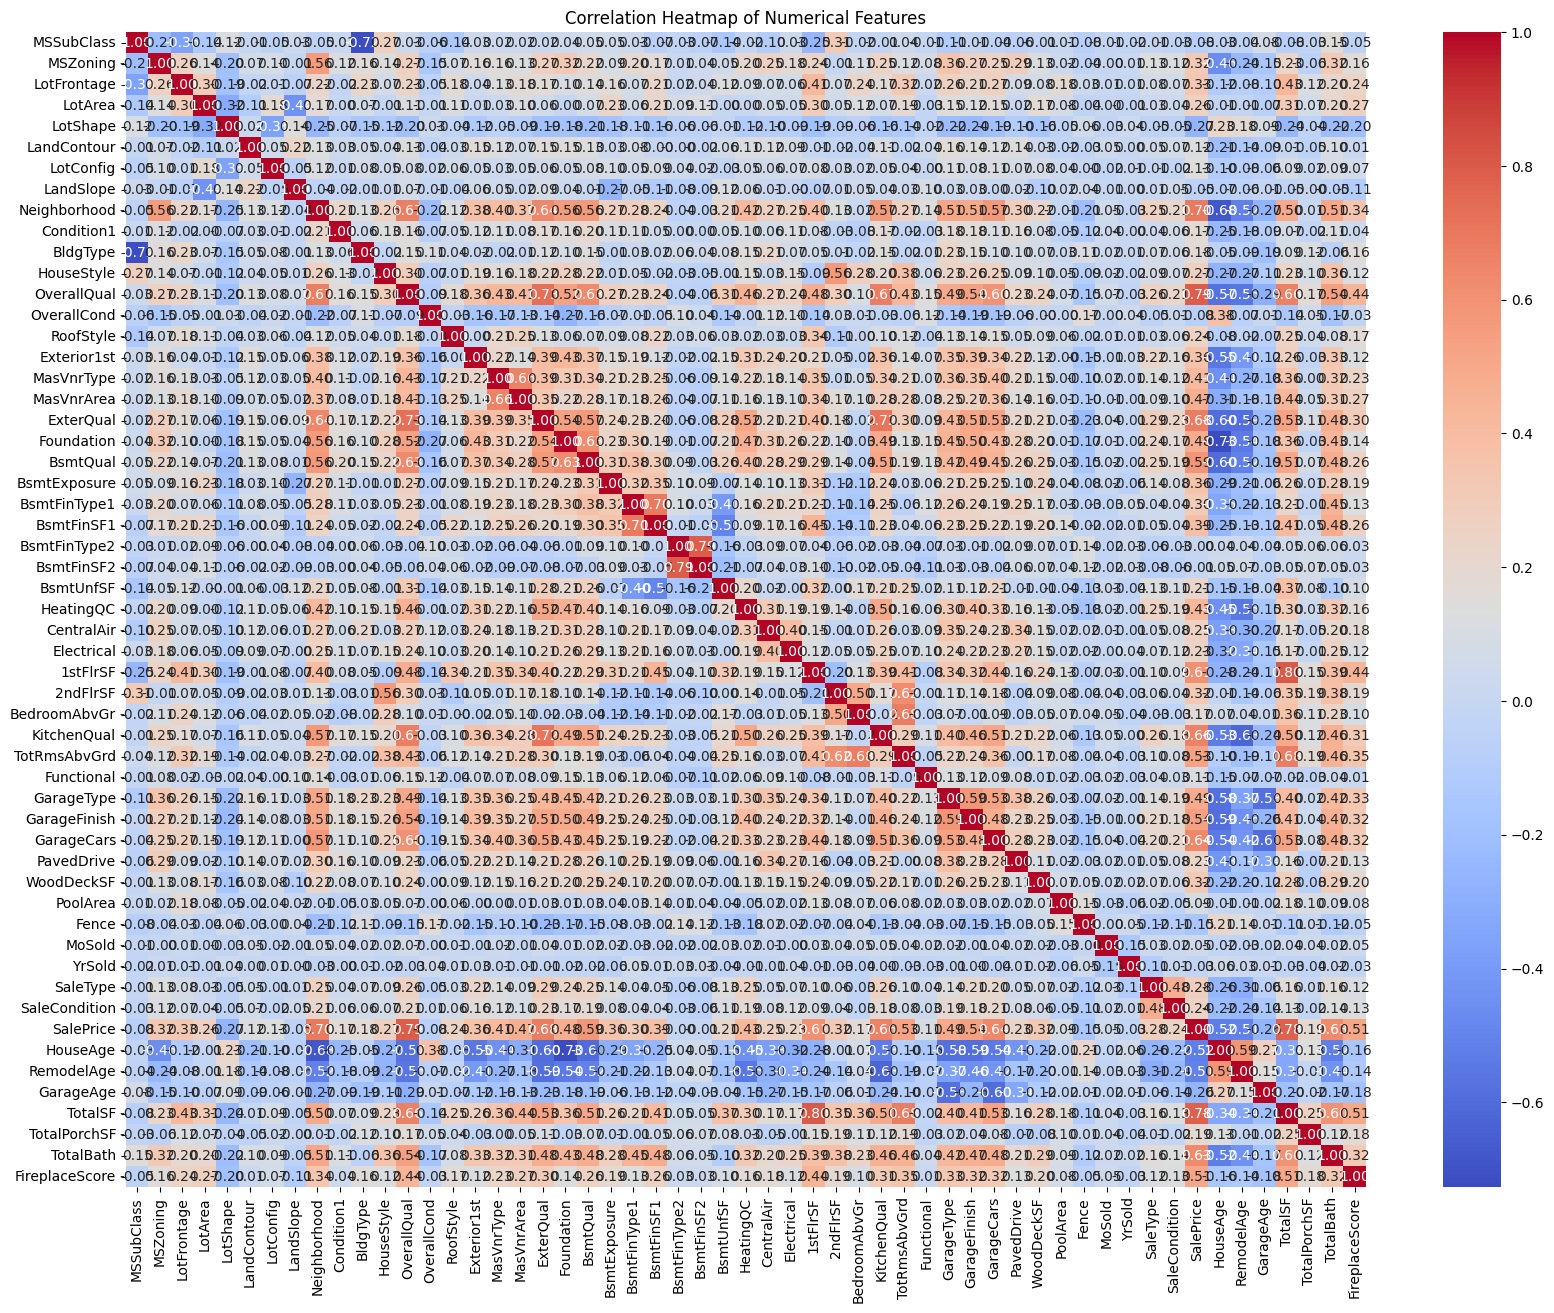

Columns included in the correlation matrix 
['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'RoofStyle', 'Exterior1st', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'GarageType', 'GarageFinish', 'GarageCars', 'PavedDrive', 'WoodDeckSF', 'PoolArea', 'Fence', 'MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice', 'HouseAge', 'RemodelAge', 'GarageAge', 'TotalSF', 'TotalPorchSF', 'TotalBath', 'FireplaceScore']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation matrix using the explicitly selected numerical columns
corr = data[numerical_cols].corr()

# Visualisasi korelasi
plt.figure(figsize=(20, 15)) # Adjust figure size for better readability
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

print("Columns included in the correlation matrix ")
print(corr.columns.tolist())

In [ ]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
correlation_with_saleprice = data[numerical_cols].corr()['SalePrice'].sort_values(ascending=False)
display(correlation_with_saleprice)

# Identify numerical columns with absolute correlation to SalePrice less than 0.2
low_corr_cols = correlation_with_saleprice[abs(correlation_with_saleprice) < 0.2].index.tolist()

# Exclude 'SalePrice' itself from the list of columns to drop if it happens to be there
if 'SalePrice' in low_corr_cols:
    low_corr_cols.remove('SalePrice')

# Drop these columns from the DataFrame
print(f"Shape before dropping low correlation numerical columns: {data.shape}")
data.drop(columns=low_corr_cols, inplace=True, errors='ignore')
print(f"Dropped columns: {low_corr_cols}")
print(f"Shape after dropping low correlation numerical columns: {data.shape}")

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
TotalSF,0.778959
Neighborhood,0.696158
ExterQual,0.682639
KitchenQual,0.659600
GarageCars,0.640409
TotalBath,0.631731
1stFlrSF,0.605852
BsmtQual,0.585207


Shape before dropping low correlation numerical columns: (1460, 55)
Dropped columns: ['TotalPorchSF', 'BldgType', 'Condition1', 'BedroomAbvGr', 'LotConfig', 'LandContour', 'Functional', 'PoolArea', 'MoSold', 'BsmtFinType2', 'BsmtFinSF2', 'YrSold', 'LandSlope', 'OverallCond', 'MSSubClass', 'Fence']
Shape after dropping low correlation numerical columns: (1460, 39)


In [ ]:
data.shape

(1460, 39)

## Saleprice

In [ ]:
data['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
data['SalePrice'].skew()

np.float64(1.8828757597682129)

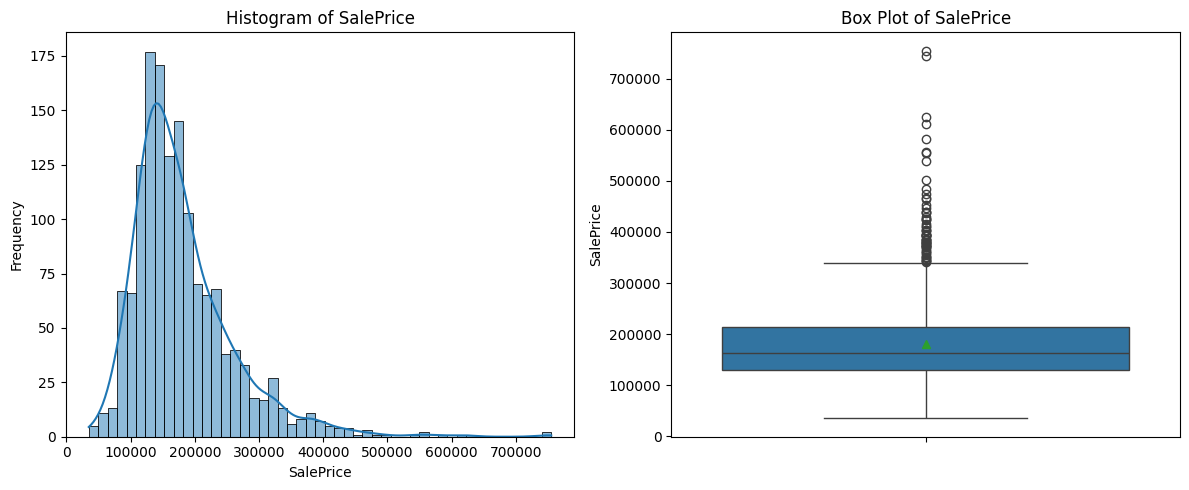


Skewness of SalePrice: 1.88


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data['SalePrice'], kde=True)
plt.title('Histogram of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=data['SalePrice'], showmeans=True)
plt.title('Box Plot of SalePrice')
plt.ylabel('SalePrice')

plt.tight_layout()
plt.show()

print(f"\nSkewness of SalePrice: {data['SalePrice'].skew():.2f}")

In [ ]:
fitur_penting = [ 'SalePrice', 'OverallQual', 'TotalSF', 'KitchenQual', 'GarageCars', 'Neighborhood', 'GarageFinish', 'TotalBath', 'BsmtQual', 'GarageType', 'CentralAir', 'RemodelAge', 'FireplaceScore' ]
outlier_data = data[data['SalePrice'] > 340037][fitur_penting].sort_values('SalePrice', ascending=False)
print(f"Jumlah outlier: {len(outlier_data)}")
display(outlier_data)

## Train Test Split

In [ ]:
# prompt: train terst split

from sklearn.model_selection import train_test_split

X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1168, 38)
Shape of X_test: (292, 38)
Shape of y_train: (1168,)
Shape of y_test: (292,)


In [ ]:
y_train.value_counts()

,count
SalePrice,
11.849405,15
11.813037,13
12.154785,12
11.608245,12
11.951187,11
...,...
12.308182,1
12.540761,1
12.146859,1


#Modelling

##Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Initialize and train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr_test = lr.predict(X_test)
y_pred_lr_train = lr.predict(X_train)

# Evaluate the model
print("\n--- Linear Regression Model Evaluation ---")

# Mean Absolute Error (MAE)
mae_lr_train = mean_absolute_error(y_train, y_pred_lr_train)
mae_lr_test = mean_absolute_error(y_test, y_pred_lr_test)
print(f"Mean Absolute Error (MAE) Train: {mae_lr_train:.4f}")
print(f"Mean Absolute Error (MAE) Test: {mae_lr_test:.4f}")

# Root Mean Squared Error (RMSE)
rmse_lr_train = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_lr_test = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
print(f"Root Mean Squared Error (RMSE) Train: {rmse_lr_train:.4f}")
print(f"Root Mean Squared Error (RMSE) Test: {rmse_lr_test:.4f}")

# Mean Absolute Percentage Error (MAPE)
mape_lr_train = mean_absolute_percentage_error(y_train, y_pred_lr_train)
mape_lr_test = mean_absolute_percentage_error(y_test, y_pred_lr_test)
print(f"Mean Absolute Percentage Error (MAPE) Train: {mape_lr_train:.2f}%")
print(f"Mean Absolute Percentage Error (MAPE) Test: {mape_lr_test:.2f}%")

# R-squared
r2_lr_train = r2_score(y_train, y_pred_lr_train)
r2_lr_test = r2_score(y_test, y_pred_lr_test)
print(f"R-squared Train: {r2_lr_train*100:.4f}%")
print(f"R-squared Test: {r2_lr_test*100:.4f}%")


--- Linear Regression Model Evaluation ---
Mean Absolute Error (MAE) Train: 20224.9746
Mean Absolute Error (MAE) Test: 20923.8229
Root Mean Squared Error (RMSE) Train: 31851.9984
Root Mean Squared Error (RMSE) Test: 33744.1530
Mean Absolute Percentage Error (MAPE) Train: 12.06%
Mean Absolute Percentage Error (MAPE) Test: 12.23%
R-squared Train: 82.9903%
R-squared Test: 85.1549%


## Random Forest


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Initialize and train Random Forest Regressor model
rf = RandomForestRegressor(random_state=42) # Added random_state for reproducibility
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf_test = rf.predict(X_test)
y_pred_rf_train = rf.predict(X_train)

# Evaluate the model
print("\n--- Random Forest Regressor Model Evaluation ---")

# Mean Absolute Error (MAE)
mae_rf_train = mean_absolute_error(y_train, y_pred_rf_train)
print(f"Mean Absolute Error (MAE) Train: {mae_rf_train:.4f}")
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)
print(f"Mean Absolute Error (MAE) Test: {mae_rf_test:.4f}")

# Root Mean Squared Error (RMSE)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
print(f"Root Mean Squared Error (RMSE)Train: {rmse_rf_train:.4f}")
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
print(f"Root Mean Squared Error (RMSE)Test: {rmse_rf_test:.4f}")

# Mean Absolute Percentage Error (MAPE)
mape_rf_train = mean_absolute_percentage_error(y_train, y_pred_rf_train)
print(f"Mean Absolute Percentage Error (MAPE) Train: {mape_rf_train:.2f}%")
# Mean Absolute Percentage Error (MAPE)
mape_rf_test = mean_absolute_percentage_error(y_test, y_pred_rf_test)
print(f"Mean Absolute Percentage Error (MAPE) Test: {mape_rf_test:.2f}%")

# R-squared
r2_rf_train = r2_score(y_train, y_pred_rf_train)
print(f"R-squared Train: {r2_rf_train*100:.4f}%")
r2_rf_test = r2_score(y_test, y_pred_rf_test)
print(f"R-squared Test: {r2_rf_test*100:.4f}%")


--- Random Forest Regressor Model Evaluation ---
Mean Absolute Error (MAE) Train: 6479.5429
Mean Absolute Error (MAE) Test: 17862.0530
Root Mean Squared Error (RMSE)Train: 10526.3088
Root Mean Squared Error (RMSE)Test: 29301.0169
Mean Absolute Percentage Error (MAPE) Train: 3.79%
Mean Absolute Percentage Error (MAPE) Test: 10.70%
R-squared Train: 98.1423%
R-squared Test: 88.8069%


## XGboost


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train,y_train)


y_pred_xgb_test = xgb.predict(X_test)
y_pred_xgb_train = xgb.predict(X_train)

# Evaluate the model
print("\n--- XGBoost Regressor Model Evaluation ---")

# Mean Absolute Error (MAE)
mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
print(f"Mean Absolute Error (MAE) Train: {mae_xgb_train:.4f}")
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
print(f"Mean Absolute Error (MAE) Test: {mae_xgb_test:.4f}")

# Root Mean Squared Error (RMSE)
rmse_xgb_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
print(f"Root Mean Squared Error (RMSE)Train: {rmse_xgb_train:.4f}")
rmse_xgb_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
print(f"Root Mean Squared Error (RMSE)Test: {rmse_xgb_test:.4f}")

# Mean Absolute Percentage Error (MAPE)
mape_xgb_train = mean_absolute_percentage_error(y_train, y_pred_xgb_train)
print(f"Mean Absolute Percentage Error (MAPE) Train: {mape_xgb_train:.2f}%")
# Mean Absolute Percentage Error (MAPE)
mape_xgb_test = mean_absolute_percentage_error(y_test, y_pred_xgb_test)
print(f"Mean Absolute Percentage Error (MAPE) Test: {mape_xgb_test:.2f}%")

# R-squared
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
print(f"R-squared Train: {r2_xgb_train*100:.4f}%")
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)
print(f"R-squared Test: {r2_xgb_test*100:.4f}%")



--- XGBoost Regressor Model Evaluation ---
Mean Absolute Error (MAE) Train: 700.8293
Mean Absolute Error (MAE) Test: 17771.3184
Root Mean Squared Error (RMSE)Train: 1000.1128
Root Mean Squared Error (RMSE)Test: 28070.5739
Mean Absolute Percentage Error (MAPE) Train: 0.46%
Mean Absolute Percentage Error (MAPE) Test: 10.84%
R-squared Train: 99.9832%
R-squared Test: 89.7272%


## XGboost Tuning

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

xgb = XGBRegressor(random_state=42)

param_grid = {
    'n_estimators': [400, 600, 800],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [3, 5],
    'reg_alpha': [0.5, 1, 5],
    'reg_lambda': [5, 10, 20]
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

# ambil model terbaik
best_xgb = random_search.best_estimator_

y_pred_xgb_tuned_test = best_xgb.predict(X_test)
y_pred_xgb_tuned_train = best_xgb.predict(X_train)

# Evaluate the model
print("\n--- XGBoost Regressor Model Evaluation (Tuned) ---")

# Mean Absolute Error (MAE)
mae_xgb_tuned_train = mean_absolute_error(y_train, y_pred_xgb_tuned_train)
print(f"Mean Absolute Error (MAE) Train: {mae_xgb_tuned_train:.4f}")
mae_xgb_tuned_test = mean_absolute_error(y_test, y_pred_xgb_tuned_test)
print(f"Mean Absolute Error (MAE) Test: {mae_xgb_tuned_test:.4f}")

# Root Mean Squared Error (RMSE)
rmse_xgb_tuned_train = np.sqrt(mean_squared_error(y_train, y_pred_xgb_tuned_train))
print(f"Root Mean Squared Error (RMSE)Train: {rmse_xgb_tuned_train:.4f}")
rmse_xgb_tuned_test = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned_test))
print(f"Root Mean Squared Error (RMSE)Test: {rmse_xgb_tuned_test:.4f}")

# Mean Absolute Percentage Error (MAPE)
mape_xgb_tuned_train = mean_absolute_percentage_error(y_train, y_pred_xgb_tuned_train)
print(f"Mean Absolute Percentage Error (MAPE) Train: {mape_xgb_tuned_train:.2f}%")
# Mean Absolute Percentage Error (MAPE)
mape_xgb_tuned_test = mean_absolute_percentage_error(y_test, y_pred_xgb_tuned_test)
print(f"Mean Absolute Percentage Error (MAPE) Test: {mape_xgb_tuned_test:.2f}%")

# R-squared
r2_xgb_tuned_train = r2_score(y_train, y_pred_xgb_tuned_train)
print(f"R-squared Train: {r2_xgb_tuned_train*100:.4f}%")
r2_xgb_tuned_test = r2_score(y_test, y_pred_xgb_tuned_test)
print(f"R-squared Test: {r2_xgb_tuned_test*100:.4f}%")


--- XGBoost Regressor Model Evaluation (Tuned) ---
Mean Absolute Error (MAE) Train: 8465.4570
Mean Absolute Error (MAE) Test: 16463.4219
Root Mean Squared Error (RMSE)Train: 12185.1739
Root Mean Squared Error (RMSE)Test: 27342.5968
Mean Absolute Percentage Error (MAPE) Train: 5.42%
Mean Absolute Percentage Error (MAPE) Test: 9.83%
R-squared Train: 97.5107%
R-squared Test: 90.2531%


## Model Comparison


In [ ]:
model_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost (Untuned)', 'XGBoost (Tuned)']
})

# Extracting MAE, MAPE, R-squared for Train and Test sets
model_summary['MAE Train'] = [mae_lr_train, mae_rf_train, mae_xgb_train, mae_xgb_tuned_train]
model_summary['MAE Test'] = [mae_lr_test, mae_rf_test, mae_xgb_test, mae_xgb_tuned_test]
model_summary['MAPE Train'] = [mape_lr_train, mape_rf_train, mape_xgb_train, mape_xgb_tuned_train]
model_summary['MAPE Test'] = [mape_lr_test, mape_rf_test, mape_xgb_test, mape_xgb_tuned_test]
model_summary['R-Square Train'] = [r2_lr_train * 100, r2_rf_train * 100, r2_xgb_train * 100, r2_xgb_tuned_train * 100]
model_summary['R-Square Test'] = [r2_lr_test * 100, r2_rf_test * 100, r2_xgb_test * 100, r2_xgb_tuned_test * 100]

# Calculate GAP MAPE and GAP R-Square
model_summary['GAP MAPE'] = abs(model_summary['MAPE Test'] - model_summary['MAPE Train'])
model_summary['GAP R-Square'] = abs(model_summary['R-Square Train'] - model_summary['R-Square Test'])

display(model_summary.set_index('Model').round(2))

,MAE Train,MAE Test,MAPE Train,MAPE Test,R-Square Train,R-Square Test,GAP MAPE,GAP R-Square
Model,,,,,,,,
Linear Regression,20224.97,20923.82,12.06,12.23,82.99,85.15,0.17,2.16
Random Forest,6479.54,17862.05,3.79,10.70,98.14,88.81,6.91,9.34
XGBoost (Untuned),700.83,17771.32,0.46,10.84,99.98,89.73,10.38,10.26
XGBoost (Tuned),8465.46,16463.42,5.42,9.83,97.51,90.25,4.41,7.26


## Feature Importance

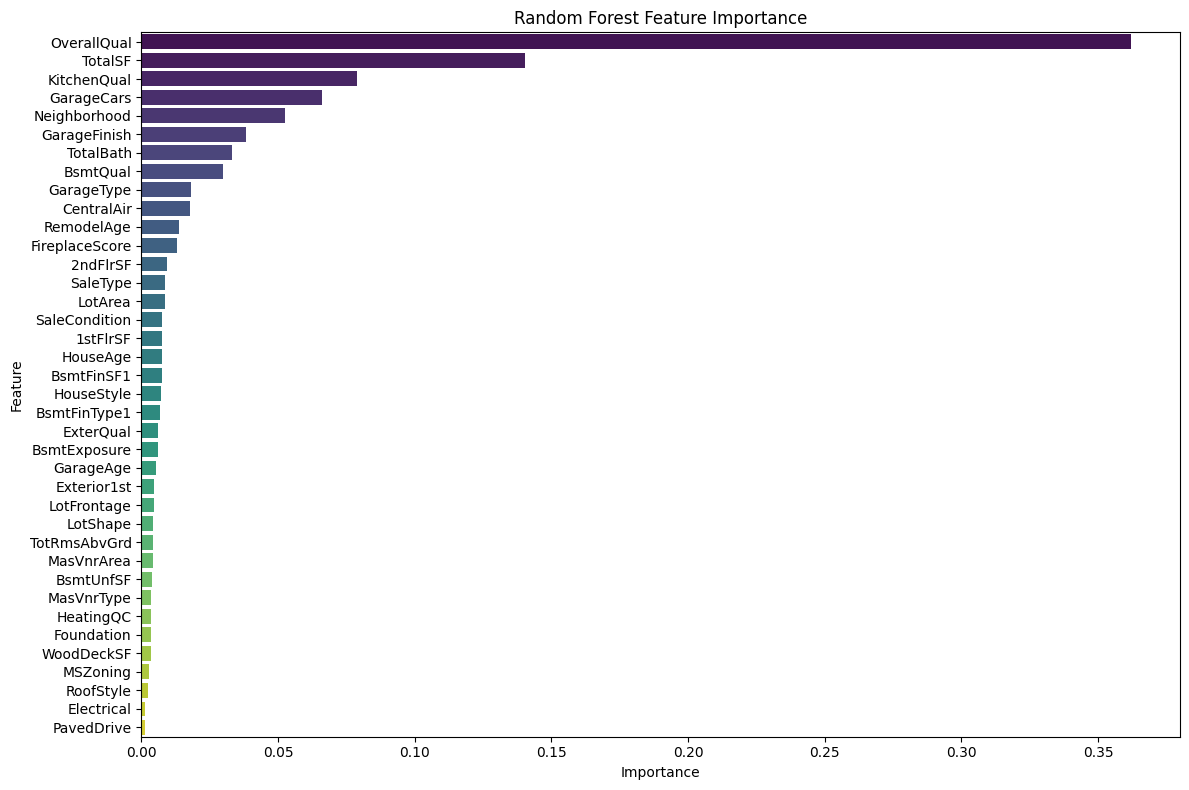

In [ ]:
# Get feature importances from the Random Forest model
feature_importances = best_xgb.feature_importances_

# Get feature names from X_train (or X_train_smote if preferred)
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate percentage importance
total_importance = importance_df['Importance'].sum()
importance_df['Percentage'] = (importance_df['Importance'] / total_importance) * 100

# Display the DataFrame with percentage
display(importance_df.round(2))

,Feature,Importance,Percentage
6,OverallQual,0.36,36.189999
35,TotalSF,0.14,14.030000
23,KitchenQual,0.08,7.900000
27,GarageCars,0.07,6.600000
4,Neighborhood,0.05,5.270000
26,GarageFinish,0.04,3.840000
36,TotalBath,0.03,3.320000
13,BsmtQual,0.03,2.980000
25,GarageType,0.02,1.820000
19,CentralAir,0.02,1.790000
